# Golf swing — predictive RL with Hill-type muscles

A parameterized upper-body skeleton driven by **antagonist Hill-type muscle**
pairs learns an efficient golf swing **from scratch** (no reference motion).
Scored only at impact:

`reward = w_ball·ball_launch_speed − w_effort·Σ(activation²)`

`ball_launch_speed` comes from an **analytic impact model** (off-center sphere
collision; smash caps ~1.5) — no flight/spin/aero simulated. It bundles clubhead
speed AND centered contact, so a fast *miss* scores 0. Effort weight is **frozen
across bodies**. Change a geometry param → rebuild → train from scratch.

The agent starts at **address** (club at the ball) and must take a real
**backswing** before impact counts — shoving the ball straight from address is
penalized, so it has to learn the full takeaway → downswing → impact motion.

All logic lives in the `rl_golf` package; this notebook just drives + looks at it.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, numpy as np, matplotlib.pyplot as plt
if os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
from rl_golf.body import BodyParams, build_mjcf
from rl_golf.swing_env import SwingEnv, ADDRESS, JOINTS
from rl_golf.viz import rollout, save_mp4, filmstrip
from rl_golf.train import make_vec_env, make_ppo, EvalVideoCallback
import mujoco
print('imports OK')

imports OK


## Body + environment

`BodyParams` sets segment lengths/masses (the geometry dials). `actuation='muscle'`
builds antagonist Hill-muscle pairs per joint (`nu=6`, with `na=6` activation
states); `'torque'` is a fast debug fallback behind the same seam.

In [2]:
body = BodyParams()
env = SwingEnv(body=body, actuation='muscle', render_mode='rgb_array')
print(f'upper_arm={body.upper_arm_length:.2f}  forearm={body.forearm_length:.2f}  '
      f'club={body.club_length:.2f}  reach={body.reach:.2f} m')
print(f'actuators(nu)={env._nu}  activation_states(na)={env._na}  '
      f'obs_dim={env.observation_space.shape[0]}  steps/episode={env.max_steps}')

upper_arm=0.32  forearm=0.30  club=1.12  reach=1.74 m
actuators(nu)=6  activation_states(na)=6  obs_dim=20  steps/episode=120


## Baseline 1 — address, muscles off

Zero excitation: the body just hangs at address (clubhead at the ball). The floor
the policy beats — `ball_speed` is 0 because nothing swings.

{'peak_speed_ms': 1.69, 'peak_speed_mph': 3.78, 'impact_speed_ms': 0.0, 'impact_speed_mph': 0.0, 'impact_dist_m': inf, 'ball_speed_mph': 0.0, 'smash_factor': 0.0, 'took_backswing': False, 'early_hit': False, 'total_effort': 178.639, 'steps': 120}


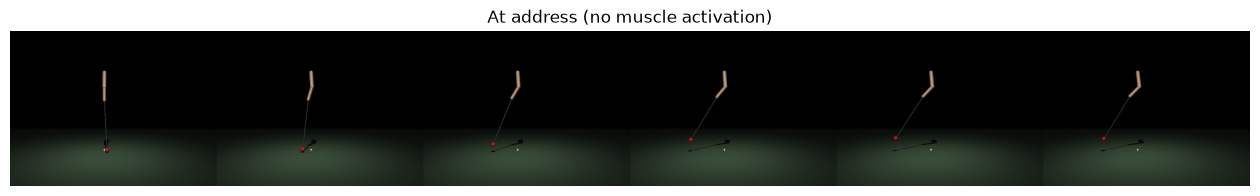

In [3]:
frames, hist, summary = rollout(env, policy=None)
print({k: round(v,3) if isinstance(v,float) else v for k,v in summary.items()})
plt.figure(figsize=(16,3)); plt.imshow(filmstrip(frames,6)); plt.axis('off')
plt.title('At address (no muscle activation)'); plt.show()

## Baseline 2 — shove from address (no backswing) → penalized

Fire the through-swing muscles straight from address, with no backswing. This is
exactly the degenerate 'hit it without taking the club back' move — so the env
flags `early_hit`, voids the ball reward, and applies the penalty. Watch the
`took_backswing` / `early_hit` flags.

took_backswing=True  early_hit=False  ball_speed=0.0 (voided if shove)


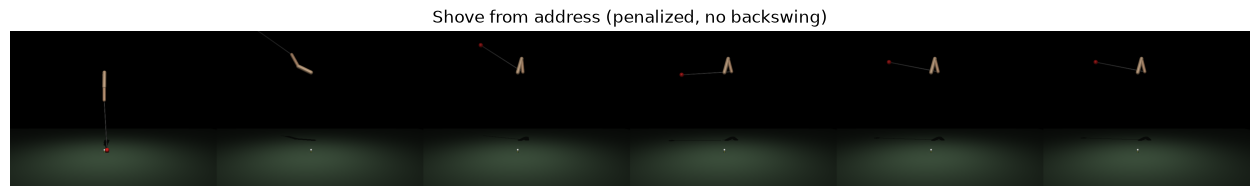

In [4]:
idx = {mujoco.mj_id2name(env.model, mujoco.mjtObj.mjOBJ_ACTUATOR, i): i for i in range(env.model.nu)}
obs,_ = env.reset(seed=0); frames=[]
for t in range(env.max_steps):
    a = -np.ones(env.action_space.shape, dtype=np.float32)  # all muscles low
    for name in ('shoulder_ext','elbow_ext','wrist_ext'): a[idx[name]] = 1.0
    obs,r,te,tr,info = env.step(a); frames.append(env.render())
    if te or tr: break
print('took_backswing=%s  early_hit=%s  ball_speed=%.1f (voided if shove)' % (
      info['took_backswing'], info['early_hit'], info['ball_speed']))
plt.figure(figsize=(16,3)); plt.imshow(filmstrip(frames,6)); plt.axis('off')
plt.title('Shove from address (penalized, no backswing)'); plt.show()

## Train PPO

Muscle control is harder than torque, so expect to need more steps. Start modest to
confirm learning, then bump `TOTAL_STEPS`. `EvalVideoCallback` drops an mp4 in
`outputs/videos/` each interval so you can watch the swing emerge.

Curves: `tensorboard --logdir outputs/tb`

In [5]:
TOTAL_STEPS = 5_000_000   # muscle control needs it; gSDE+entropy keep it exploring
venv  = make_vec_env(body=body, n_envs=8)            # actuation defaults to muscle
model = make_ppo(venv)   # gSDE + ent_coef on; reward now dominated by ball speed
cb    = EvalVideoCallback(body=body, every=100_000, verbose=1)
model.learn(total_timesteps=TOTAL_STEPS, callback=cb, progress_bar=True)
model.save('outputs/ppo_swing'); print('saved -> outputs/ppo_swing.zip')

Using cpu device
Logging to outputs/tb/PPO_11


/Users/morgancooper/miniconda3/envs/rl-golf/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

------------------------------
| time/              |       |
|    fps             | 8809  |
|    iterations      | 1     |
|    time_elapsed    | 1     |
|    total_timesteps | 16384 |
------------------------------
---------------------------------------
| time/                   |           |
|    fps                  | 5449      |
|    iterations           | 2         |
|    time_elapsed         | 6         |
|    total_timesteps      | 32768     |
| train/                  |           |
|    approx_kl            | 1.9345798 |
|    clip_fraction        | 0.857     |
|    clip_range           | 0.2       |
|    entropy_loss         | -21.3     |
|    explained_variance   | -0.0087   |
|    learning_rate        | 0.0003    |
|    loss                 | 5.98      |
|    n_updates            | 10        |
|    policy_gradient_loss | 0.138     |
|    std                  | 0.979     |
|    value_loss           | 9.82      |
---------------------------------------
-----------------------

[eval @ 100000] impact=1 mph -> outputs/videos/swing_00100000.mp4

-----------------------------------------
| time/                   |             |
|    fps                  | 4291        |
|    iterations           | 7           |
|    time_elapsed         | 26          |
|    total_timesteps      | 114688      |
| train/                  |             |
|    approx_kl            | 0.016835049 |
|    clip_fraction        | 0.184       |
|    clip_range           | 0.2         |
|    entropy_loss         | -22.4       |
|    explained_variance   | 0.388       |
|    learning_rate        | 0.0003      |
|    loss                 | 3.5         |
|    n_updates            | 60          |
|    policy_gradient_loss | -0.0122     |
|    std                  | 0.915       |
|    value_loss           | 12.1        |
-----------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 4236        |
|    iterations           | 8           |
|    time_elapsed         | 30    

...

[eval @ 4900000] impact=31 mph -> outputs/videos/swing_04900000.mp4

-----------------------------------------
| time/                   |             |
|    fps                  | 438         |
|    iterations           | 300         |
|    time_elapsed         | 11200       |
|    total_timesteps      | 4915200     |
| train/                  |             |
|    approx_kl            | 0.010042911 |
|    clip_fraction        | 0.114       |
|    clip_range           | 0.2         |
|    entropy_loss         | -22.6       |
|    explained_variance   | 1           |
|    learning_rate        | 0.0003      |
|    loss                 | 15.8        |
|    n_updates            | 2990        |
|    policy_gradient_loss | -0.0143     |
|    std                  | 0.72        |
|    value_loss           | 46.2        |
-----------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 440         |
|    iterations           | 301         |
|    time_elapsed         | 11204 

[eval @ 5000000] impact=30 mph -> outputs/videos/swing_05000000.mp4

-----------------------------------------
| time/                   |             |
|    fps                  | 437         |
|    iterations           | 306         |
|    time_elapsed         | 11463       |
|    total_timesteps      | 5013504     |
| train/                  |             |
|    approx_kl            | 0.009908391 |
|    clip_fraction        | 0.0973      |
|    clip_range           | 0.2         |
|    entropy_loss         | -22.6       |
|    explained_variance   | 1           |
|    learning_rate        | 0.0003      |
|    loss                 | 23.9        |
|    n_updates            | 3050        |
|    policy_gradient_loss | -0.0133     |
|    std                  | 0.719       |
|    value_loss           | 52.8        |
-----------------------------------------


saved -> outputs/ppo_swing.zip


## Watch the trained swing

In [6]:
env = SwingEnv(body=body, actuation='muscle', render_mode='rgb_array')
frames, hist, summary = rollout(env, policy=model, deterministic=True)
print({k: round(v,3) for k,v in summary.items()})
save_mp4(frames, 'outputs/videos/trained_swing.mp4', fps=50)
plt.figure(figsize=(16,3)); plt.imshow(filmstrip(frames,6)); plt.axis('off')
plt.title(f"Trained swing — clubhead {summary['impact_speed_mph']:.0f} mph, "
          f"ball {summary['ball_speed_mph']:.0f} mph, smash {summary['smash_factor']:.2f}"); plt.show()

ValueError: Error: Unexpected observation shape (30,) for Box environment, please use (20,) or (n_env, 20) for the observation shape.

In [ ]:
from IPython.display import Video
Video('outputs/videos/trained_swing.mp4', embed=True, width=640)

## Diagnostics

Clubhead speed should peak **at** the bottom of the arc (impact), where distance to
the strike point is minimized. Effort (Σactivation²) accumulates over the swing.

In [ ]:
speed = np.array([h['clubhead_speed'] for h in hist])
dist  = np.array([h['impact_dist']  for h in hist])  # running min distance
t = np.arange(len(hist)) * env.dt
fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(t, speed*2.237); ax[0].set_xlabel('time (s)'); ax[0].set_ylabel('mph')
ax[0].set_title(f"Clubhead speed (impact {summary['impact_speed_mph']:.0f} mph, "
                f"effort {summary['total_effort']:.0f})")
ax[1].plot(t, dist); ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('m')
ax[1].set_title('Closest approach to strike point'); plt.tight_layout(); plt.show()

## Next (per the brief)

- **Lock a validated nominal swing**: tune muscle strengths so clubhead tops out at
  a realistic ~100–120 mph with a sensible proximal→distal sequence.
- **Go 3D**: add pelvis + thorax so X-factor, swing-plane angle, side-bend, and the
  full kinematic sequence become measurable (the real dependent variables).
- **Free setup**: let the agent choose its own address posture.
- **Sweep geometry**: rebuild + cold-start train per body, 3–5 seeds, compare
  distributions (a geometry effect must exceed the seed spread).